# Student Performance Classification

Tasks 8 & 9: Neural Network + Optimizer Comparison (SGD, Adadelta, Adam)

---
## Task 8: Student Exam Performance Prediction
Classify students' final exam performance (pass/fail) based on attendance percentage and assignment scores.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [11]:

# Load dataset
df = pd.read_csv("datasets\\student_performance_dataset.csv")

df.head()


,Attendance (%),Assignment Score,Final Score (hidden),Performance
0,78,86,82.8,High
1,91,45,63.4,Medium
2,68,85,78.2,High
3,54,39,45.0,Low
4,82,59,68.2,Medium


In [3]:

# Features and labels
X = df[["Attendance (%)", "Assignment Score"]]
y = df["Performance"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:

def create_model(optimizer):
    model = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


---
## Task 9: Compare SGD vs Adadelta vs Adam Optimizers
Train the same model architecture with three different optimizers on the job dataset. Plot their loss and accuracy curves and explain the differences.

In [5]:

optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "Adadelta": keras.optimizers.Adadelta(),
    "Adam": keras.optimizers.Adam()
}

histories = {}
results = {}

for name, opt in optimizers.items():
    print(f"Training with {name}...")
    model = create_model(opt)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    histories[name] = history
    results[name] = acc

results


Training with SGD...


c:\Users\mhamz\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Adadelta...
Training with Adam...


{'SGD': 0.987500011920929,
 'Adadelta': 0.3449999988079071,
 'Adam': 0.9900000095367432}

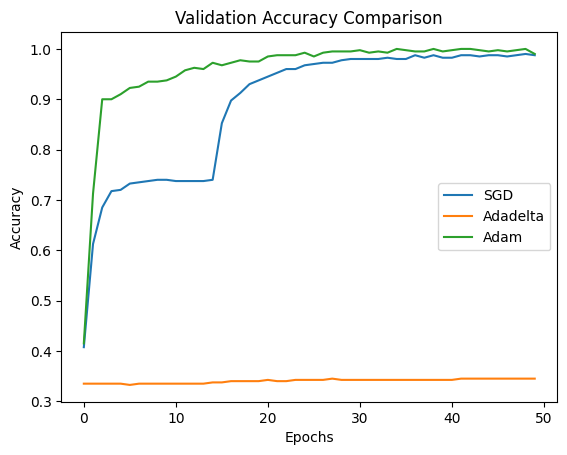

In [6]:

plt.figure()
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


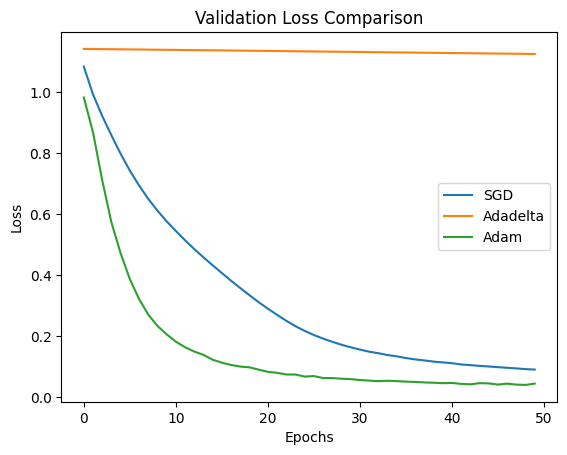

In [7]:

plt.figure()
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Explanation of Results

- **SGD**: Slower convergence and may get stuck in local minima.
- **Adadelta**: Adapts learning rates dynamically, more stable than SGD.
- **Adam**: Fastest convergence and usually highest accuracy due to adaptive learning rates and momentum.

### Conclusion:
Adam generally performs best for this dataset, followed by Adadelta, while SGD is slower.
